In [32]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

In [34]:
# Read in the image
img = Image.open("killian.png").convert("RGB")

In [35]:
# Convert the image to a NumPy array and normalize it
img_arr = np.array(img) / 255.0

In [36]:
img_arr.shape

(411, 583, 3)

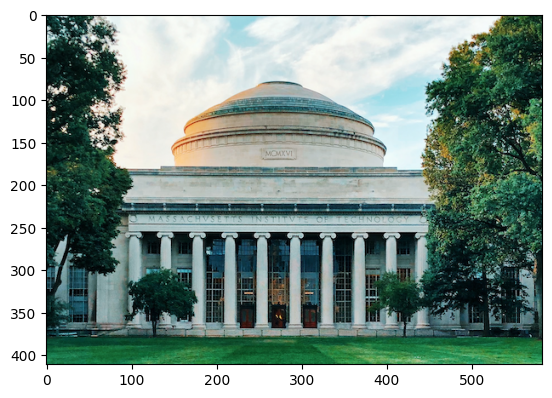

In [37]:
plt.imshow(img_arr)

Let's add some "noise" to it:

For each pixel, we sample a zero-mean normal random variable (with a small standard deviation) and add it to the pixel value.

In [38]:
# 'scale' is the standard deviation

noisy_img = img_arr + np.random.normal(scale=0.3, size=img_arr.shape)

In [39]:
img_arr[0,:,:]

array([[0.23137255, 0.45098039, 0.36470588],
       [0.15294118, 0.36078431, 0.29411765],
       [0.04705882, 0.18431373, 0.16078431],
       ...,
       [0.09019608, 0.23921569, 0.15294118],
       [0.05490196, 0.19607843, 0.11372549],
       [0.03529412, 0.14509804, 0.08235294]])

In [40]:
noisy_img[0,:,:]

array([[ 0.1821957 ,  0.53667873,  0.34603336],
       [-0.17237949,  0.354843  ,  0.71745062],
       [ 0.14133709,  0.30915192,  0.09809061],
       ...,
       [ 0.10688226,  0.10405786, -0.27199665],
       [ 0.68073241,  0.30044477,  0.22791837],
       [-0.37920481,  0.38031783, -0.07194509]])

Since some of the values may be smaller than 0.0 or greater than 1.0, we "**clip**" it:

values smaller than 0.0 are set to 0.0 and values greater than 1.0 are set to 1.0.

In [41]:
noisy_img = np.clip(noisy_img, 0.0, 1.0)

Let's see how the noise-added image looks.

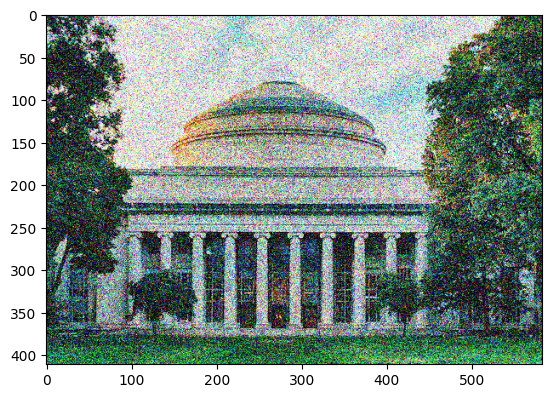

In [42]:
plt.imshow(noisy_img)

Let's generate a whole sequence of increasingly noisy images by placing the above code in a loop and increasing the standard deviation.

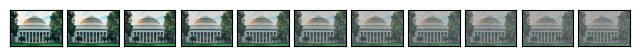

In [43]:
# Set the figure size and spacing
fig = plt.figure(figsize=(8, 2))
fig.subplots_adjust(wspace=0.1)

# Show the original image
ax = fig.add_subplot(1, 11, 1)
ax.imshow(img_arr, cmap='gray', vmin=0, vmax=1)
ax.set_xticks([])
ax.set_yticks([])

# Add increasing amounts of Gaussian noise
# i.e. increase the standard deviation of the normal RV
# and display the resulting images

for i, sigma in enumerate(np.arange(0, 1.1, 0.1)):
    # sigma (i.e. the standard dev) takes on 0, 0.1, 0.2, ..., 1.0
    noisy_img = img_arr + np.random.normal(scale=sigma, size=img_arr.shape)
    noisy_img = np.clip(noisy_img, 0.0, 1.0)
    ax = fig.add_subplot(1, 11, i+1)
    ax.imshow(noisy_img, cmap='gray', vmin=0, vmax=1)
    ax.set_xticks([])
    ax.set_yticks([])

plt.show()
